In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv('../DATA/Raw/ai4i2020.csv')
print("Shape", df.shape)
display(df.head(5))

Shape (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Loaded: (10000, 14)


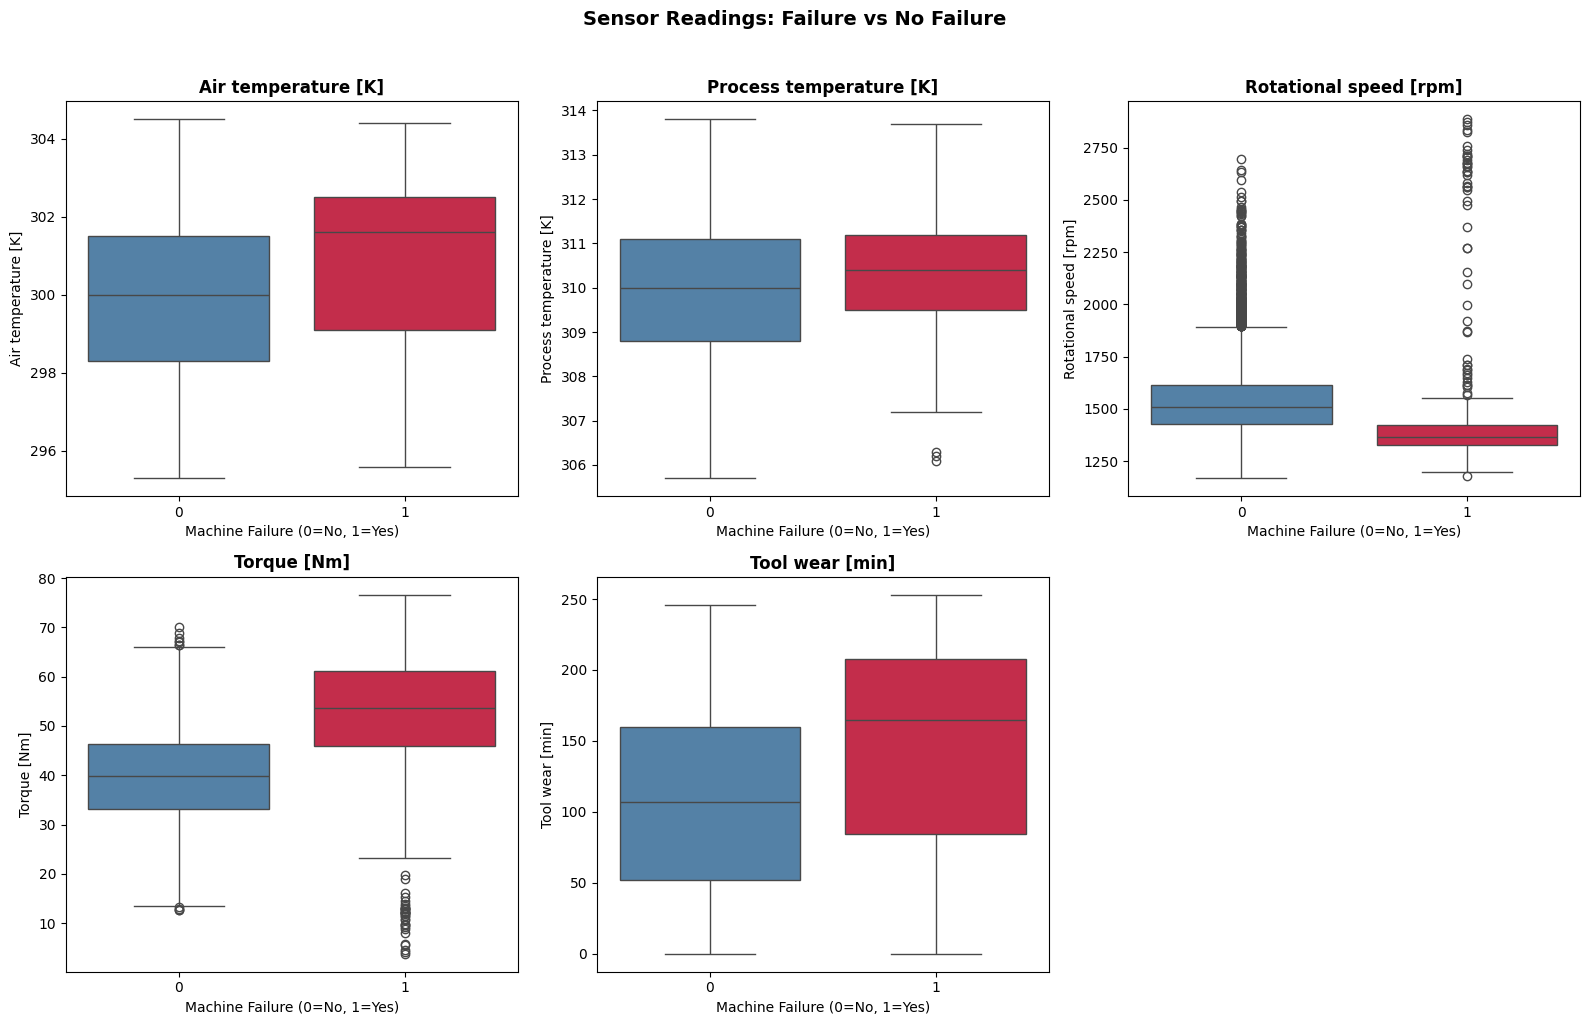

── Mean Sensor Values: Failure vs No Failure ──


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


In [2]:
#SESSION 4: BI-VARIATE ANALYSIS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


failure_types=['TWF','HDF','PWF','OSF','RNF']
sensor_cols=['Air temperature [K]',
             'Process temperature [K]',
             'Rotational speed [rpm]',
             'Torque [Nm]',
             'Tool wear [min]']

print("Loaded:",df.shape)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    sns.boxplot(data=df, x='Machine failure',
                y=col, ax=axes[i],
                hue='Machine failure',
                palette={0: 'steelblue', 1: 'crimson'},
                legend=False)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Machine Failure (0=No, 1=Yes)')

axes[5].axis('off')  # hide empty 6th subplot

plt.suptitle('Sensor Readings: Failure vs No Failure',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/sensor_vs_failure.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Numerical comparison
print("── Mean Sensor Values: Failure vs No Failure ──")
comparison = df.groupby('Machine failure')[sensor_cols].mean()
display(comparison.round(2))

── Failure Rate by Product Type ──


,Total_Units,Failures,Failure_Rate
Type,,,
H,1003,21,2.09
L,6000,235,3.92
M,2997,83,2.77


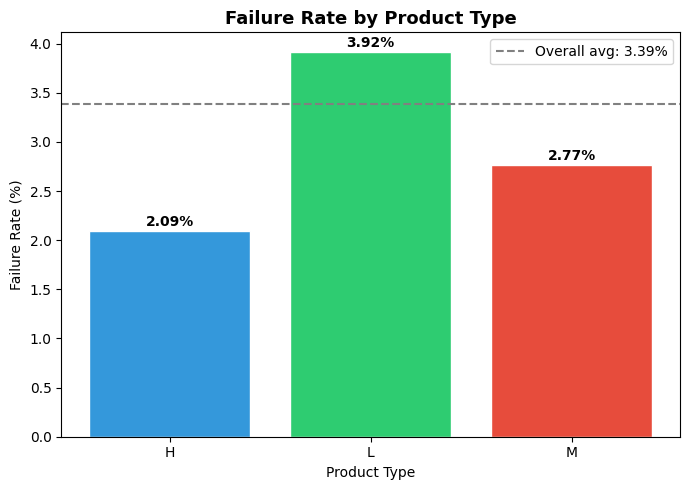

In [3]:
# Failure rate per product type
type_failure = (df.groupby('Type')['Machine failure']
                .agg(['count', 'sum', 'mean']))
type_failure.columns = ['Total_Units',
                        'Failures',
                        'Failure_Rate']
type_failure['Failure_Rate'] = (
    type_failure['Failure_Rate'] * 100).round(2)

print("── Failure Rate by Product Type ──")
display(type_failure)

# Visualize
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(type_failure.index,
               type_failure['Failure_Rate'],
               color=['#3498DB', '#2ECC71', '#E74C3C'],
               edgecolor='white')

for bar, val in zip(bars, type_failure['Failure_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.05, f'{val}%',
            ha='center', fontweight='bold')

ax.set_title('Failure Rate by Product Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Product Type')
ax.set_ylabel('Failure Rate (%)')
ax.axhline(3.39, color='grey', linestyle='--',
          label='Overall avg: 3.39%')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/failure_by_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

── Temperature Differential Summary ──
count    10000.0
mean        10.0
std          1.0
min          7.6
25%          9.3
50%          9.8
75%         11.0
max         12.1
Name: temp_diff, dtype: float64


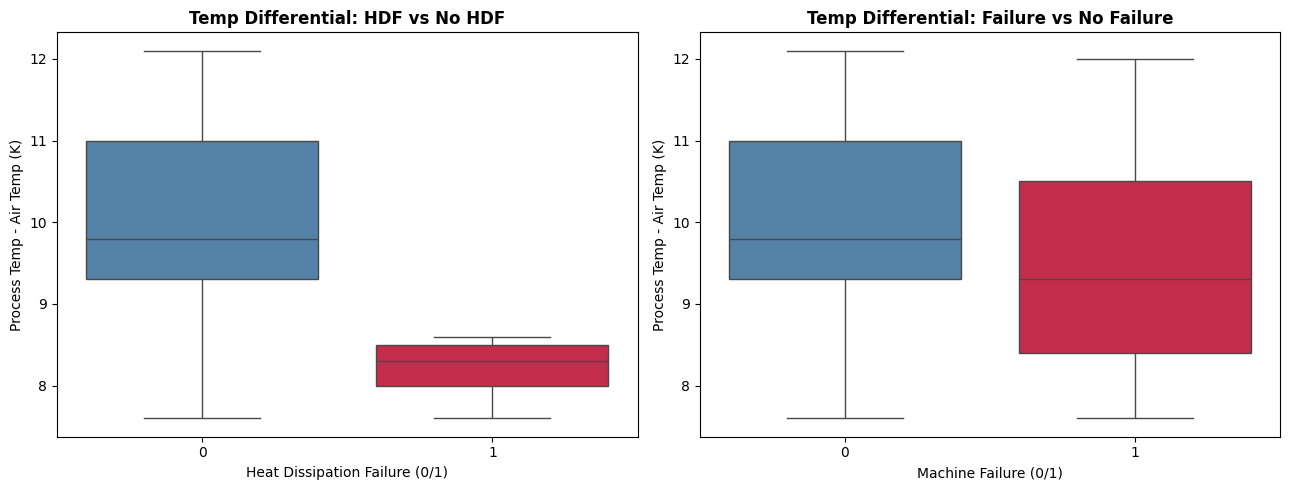


── Mean Temp Differential ──
HDF=0: 10.02
HDF=1: 8.23


In [4]:
# Engineer temperature differential
df['temp_diff'] = (df['Process temperature [K]']
                   - df['Air temperature [K]'])

print("── Temperature Differential Summary ──")
print(df['temp_diff'].describe().round(2))

# Compare temp_diff: HDF vs non-HDF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='HDF', y='temp_diff',
           ax=axes[0], hue='HDF',
           palette={0: 'steelblue', 1: 'crimson'},
           legend=False)
axes[0].set_title('Temp Differential: HDF vs No HDF',
                  fontweight='bold')
axes[0].set_xlabel('Heat Dissipation Failure (0/1)')
axes[0].set_ylabel('Process Temp - Air Temp (K)')

# Compare temp_diff: Overall failure vs not
sns.boxplot(data=df, x='Machine failure',
           y='temp_diff', ax=axes[1],
           hue='Machine failure',
           palette={0: 'steelblue', 1: 'crimson'},
           legend=False)
axes[1].set_title('Temp Differential: Failure vs No Failure',
                  fontweight='bold')
axes[1].set_xlabel('Machine Failure (0/1)')
axes[1].set_ylabel('Process Temp - Air Temp (K)')

plt.tight_layout()
plt.savefig('../assets/temp_differential.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Numerical proof
print("\n── Mean Temp Differential ──")
print(f"HDF=0: {df[df['HDF']==0]['temp_diff'].mean():.2f}")
print(f"HDF=1: {df[df['HDF']==1]['temp_diff'].mean():.2f}")